<a href="https://colab.research.google.com/github/ms7212441-lang/ML-/blob/main/ml_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

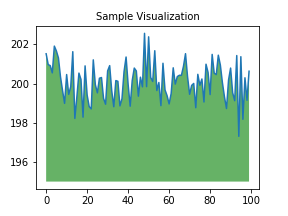

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Original Dataset:
     Feature1  Feature2  Feature3  Feature4
0        2.5       2.4       1.2       0.5
1        0.5       0.7       0.3       0.2
2        2.2       2.9       1.5       0.7
3        1.9       2.2       1.1       0.4
4        3.1       3.0       1.8       0.9
5        2.3       2.7       1.3       0.6
6        2.0       1.6       0.9       0.3
7        1.0       1.1       0.4       0.2
8        1.5       1.6       0.6       0.3
9        1.1       0.9       0.5       0.2
10       2.7       2.6       1.4       0.6
11       3.0       3.2       1.9       1.0
12       2.9       2.8       1.7       0.8
13       1.8       1.9       1.0       0.4
14       1.2       1.3       0.5       0.2
15       2.4       2.5       1.3       0.6
16       2.6       2.7       1.5       0.7
17       1.3       1.4       0.6       0.3
18       1.7       1.8       0.9       0.4
19       2.8       2.9       1.6       0.8

PCA Transformed Data:
          PC1       PC2
0   0.612441 -0.486159
1  -3.43

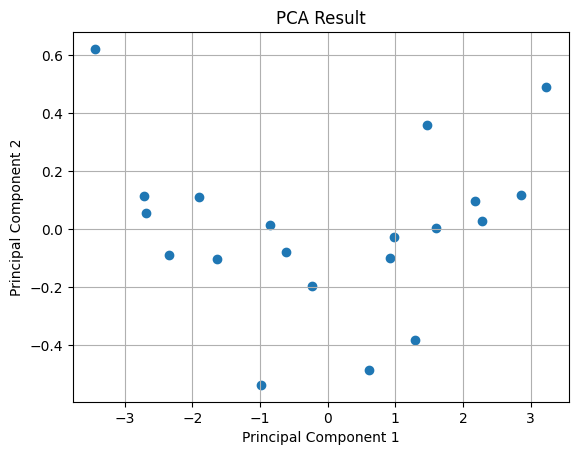

In [ ]:
 import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = pd.read_csv("data.csv")

print("Original Dataset:\n", data)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

print("\nPCA Transformed Data:\n", pca_df)

print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.grid()
plt.show()

### PCA Algorithm and Pseudocode

**Algorithm Steps:**
1. **Standardization:** Scale the features so they have a mean of 0 and a variance of 1. This ensures that features with larger scales don't dominate the results.
2. **Covariance Matrix:** Calculate the covariance matrix to understand how variables in the dataset vary with respect to each other.
3. **Eigen-decomposition:** Compute the eigenvectors and eigenvalues of the covariance matrix. Eigenvectors represent the directions of maximum variance (principal components), and eigenvalues represent the magnitude of that variance.
4. **Sort and Select:** Sort the eigenvalues in descending order and select the top $k$ eigenvectors to form a projection matrix.
5. **Projection:** Transform the original data into the new $k$-dimensional subspace.

**Pseudocode:**
```text
ALGORITHM PrincipalComponentAnalysis(Data X, k):
    1. X_scaled = (X - mean(X)) / std_dev(X)
    2. CovMatrix = (1 / n-1) * (X_scaled_transpose * X_scaled)
    3. [Eigenvectors, Eigenvalues] = ComputeEigen(CovMatrix)
    4. Sort Eigenvectors by Eigenvalues descending
    5. TopK_Vectors = Select first k Eigenvectors
    6. Projected_Data = X_scaled * TopK_Vectors
    RETURN Projected_Data
```